# Two-Player Shapley: Motif Syntax vs Background

For each sequence we define two players:
- **Motif syntax**: all annotated motifs treated as a single unit
- **Background**: everything outside the motif regions

Four coalition values:
| Coalition | Construction |
|-----------|-------------|
| `v({})` | Fully dinuc-shuffled sequence (baseline) |
| `v({motif})` | Original motifs placed into a shuffled background |
| `v({bg})` | Shuffled motifs placed into the original background |
| `v({motif, bg})` | Wild-type sequence |

Shapley values:
- `φ(motif) = ½[v({m}) - v({})] + ½[v({m,bg}) - v({bg})]`
- `φ(bg)    = ½[v({bg}) - v({})] + ½[v({m,bg}) - v({m})]`

In [2]:
import os, sys, copy, re, ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.fx as fx
import matplotlib.pyplot as plt

from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle, multisubstitute
from tangermeme.predict import predict

REPO = '/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/Replicating_Motif_Swap_Manuscript'
DATA_DIR = os.path.join(os.path.dirname(REPO), 'Motif_Context_SII', 'data')
RESULTS_DIR = os.path.join(os.path.dirname(REPO), 'Motif_Context_SII', 'results')

In [3]:
# Load manually curated clean hits for both Dev and Hk
HEADS = {
    'Dev': {'head_idx': 0, 'hits_prefix': '{bin}_clean_hits_seq',
            'real_col': 'real_Dev', 'pred_col': 'pred_Dev',
            'lib_subdir': 'Dev_full_data'},
    'Hk':  {'head_idx': 1, 'hits_prefix': '{bin}_clean_hits_Hk_seq',
            'real_col': 'real_Hk',  'pred_col': 'pred_Hk',
            'lib_subdir': 'Hk_full_data'},
}

hits = {}       # hits[head][bin] = DataFrame
hits_byseq = {} # hits[head][bin][seq_name] = DataFrame
valid_seqs = {} # valid_seqs[head][bin] = array of seq names

for head, cfg in HEADS.items():
    hits[head] = {}
    hits_byseq[head] = {}
    valid_seqs[head] = {}
    for bin_name in ['high', 'mid', 'low']:
        fname = cfg['hits_prefix'].format(bin=bin_name) + '.csv'
        df = pd.read_csv(os.path.join(DATA_DIR, fname))
        hits[head][bin_name] = df
        hits_byseq[head][bin_name] = dict(tuple(df.groupby('sequence_name')))
        valid_seqs[head][bin_name] = df['sequence_name'].unique()
        print(f'{head} {bin_name}: {len(df)} hits, {df.sequence_name.nunique()} sequences')

Dev high: 295 hits, 110 sequences
Dev mid: 233 hits, 110 sequences
Dev low: 222 hits, 110 sequences
Hk high: 257 hits, 110 sequences
Hk mid: 278 hits, 110 sequences
Hk low: 231 hits, 110 sequences


In [4]:
# Load binned library dataframes for both Dev and Hk

_DTYPE_DEVICE_RE = re.compile(r",(?:\s*dtype\s*=\s*[\w\.]+|\s*device\s*=\s*[^)\]]+)\s*\)?\s*$")

def _extract_bracket_payload(s: str) -> str:
    s = s.strip()
    if s.startswith("tensor(") and s.endswith(")"):
        s = s[len("tensor("):-1].strip()
    start = s.find('[')
    if start < 0:
        raise ValueError("No bracketed payload in string")
    s = _DTYPE_DEVICE_RE.sub("", s)
    depth = 0
    end = None
    for i, ch in enumerate(s[start:], start=start):
        if ch == '[': depth += 1
        elif ch == ']':
            depth -= 1
            if depth == 0:
                end = i + 1
                break
    if end is None:
        raise ValueError("Unbalanced brackets in payload")
    return s[start:end]

def str_tensor_to_torch(s, dtype=None, device=None):
    if s is None: return None
    payload = _extract_bracket_payload(str(s))
    data = ast.literal_eval(payload)
    return torch.tensor(data, dtype=dtype or torch.float32, device=device)

def restore_tensor_columns(df, cols, dtypes, device=None):
    for col in cols:
        if col in df.columns:
            dt = dtypes.get(col, torch.float32)
            df[col] = [str_tensor_to_torch(v, dtype=dt, device=device)
                       if isinstance(v, str) else v for v in df[col].tolist()]
    return df

COL_DTYPES = {"ohe_seq": torch.int8}

# bin_data[head][bin] = {'ohe': array of tensors, 'df': DataFrame}
bin_data = {}
for head, cfg in HEADS.items():
    bin_data[head] = {}
    for bin_name in ['high', 'mid', 'low']:
        df = pd.read_csv(os.path.join(REPO, 'experimental_library_generation',
                                       'Binned_libraries', cfg['lib_subdir'], f'{bin_name}_df.csv'))
        df = restore_tensor_columns(df, cols=["ohe_seq"], dtypes=COL_DTYPES)
        bin_data[head][bin_name] = {'ohe': df["ohe_seq"].values, 'df': df}
        print(f'{head} {bin_name}: {len(df)} seqs, OHE shape = {df["ohe_seq"].iloc[0].shape}')

Dev high: 3000 seqs, OHE shape = torch.Size([4, 249])
Dev mid: 3000 seqs, OHE shape = torch.Size([4, 249])
Dev low: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk high: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk mid: 3000 seqs, OHE shape = torch.Size([4, 249])
Hk low: 3000 seqs, OHE shape = torch.Size([4, 249])


In [5]:
# Load EvoAug distilled student model (same pattern as Hk_swap.ipynb, Dev_swap.ipynb, etc.)
model_dir  = "/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/models/EvoAug_Distilled_Student_Model"
model_path = os.path.join(model_dir, "EvoAug_student_model.pt")

# distill_EvoAug2.py must be on sys.path so pickle can resolve UncertaintyAwareStudent
sys.path.insert(0, model_dir)
import distill_EvoAug2 as distill_mod  # noqa: F401 (needed for unpickling)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model = torch.load(model_path, map_location=device, weights_only=False).to(device).eval()

# Head indices: 0=Dev, 1=Hk
DEV_IDX = 0
HK_IDX = 1
print(f"Model loaded on {device}")

Model loaded on cuda


In [6]:
def get_spacings(regions):
    """Compute inter-motif spacings from sorted start/end regions."""
    starts = regions['start'].to_numpy()
    ends = regions['end'].to_numpy()
    spacings = (starts[1:] - ends[:-1]).astype(int).tolist() if len(starts) > 1 else []
    return spacings

def build_coalitions(ohe, regions, n_shuf=10):
    """
    Build the 4 coalition sequences for a 2-player Shapley game.
    
    Each coalition is marginalized over its own independent set of
    dinucleotide shuffles so that the expectation is taken before
    the Shapley decomposition.
    
    Returns dict with keys: 'wt', 'empty', 'motif_only', 'bg_only'
    Each value is a tensor of shape (n_shuf, C, L) except 'wt' which is (1, C, L).
    """
    starts = regions['start'].to_numpy()
    ends = regions['end'].to_numpy()
    spacings = get_spacings(regions)
    
    ohe_batch = ohe.unsqueeze(0)  # (1, C, L)
    
    def _shuffle_batch(n):
        """Generate n independent dinucleotide shuffles."""
        shuf = dinucleotide_shuffle(ohe_batch, n=n)
        if shuf.ndim == 4:
            if shuf.shape[0] == n:
                shuf = shuf.squeeze(1)
            elif shuf.shape[1] == n:
                shuf = shuf.squeeze(0)
        return shuf  # (n, C, L)
    
    # Independent shuffle sets for each coalition
    shuf_empty = _shuffle_batch(n_shuf)      # for v({})
    shuf_motif = _shuffle_batch(n_shuf)      # for v({motif}) — independent bg shuffles
    shuf_bg    = _shuffle_batch(n_shuf)      # for v({bg})    — independent motif shuffles
    
    # Extract original motifs
    orig_motifs = [ohe[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]
    
    motif_only_list = []  # v({motif}): orig motifs into shuffled bg
    bg_only_list = []     # v({bg}): shuffled motifs into orig bg
    
    for i in range(n_shuf):
        # v({motif}): place original motifs into independently shuffled background
        motif_in_shuf = multisubstitute(
            shuf_motif[i].unsqueeze(0), orig_motifs,
            spacing=spacings, start=int(starts[0])
        )
        motif_only_list.append(motif_in_shuf.squeeze(0))
        
        # v({bg}): place independently shuffled motifs into original background
        shuf_motifs_i = [shuf_bg[i, :, int(s):int(e)].unsqueeze(0)
                         for s, e in zip(starts, ends)]
        shuf_in_orig = multisubstitute(
            ohe_batch, shuf_motifs_i,
            spacing=spacings, start=int(starts[0])
        )
        bg_only_list.append(shuf_in_orig.squeeze(0))
    
    return {
        'wt': ohe_batch,                          # (1, C, L)
        'empty': shuf_empty,                       # (n_shuf, C, L)
        'motif_only': torch.stack(motif_only_list), # (n_shuf, C, L)
        'bg_only': torch.stack(bg_only_list),       # (n_shuf, C, L)
    }

print("Coalition builder ready — independent shuffles per coalition")

Coalition builder ready — independent shuffles per coalition


In [7]:
# Run 2-player Shapley game for both Dev and Hk
N_SHUF = 20
BATCH_SIZE = 256
n_seqs = 100  # per bin

rows = []

for head, cfg in HEADS.items():
    head_idx = cfg['head_idx']
    real_col = cfg['real_col']
    pred_col = cfg['pred_col']
    
    print(f"\n{'='*50}")
    print(f"Processing {head} (head_idx={head_idx})")
    print(f"{'='*50}")
    
    for bin_name in ['high', 'mid', 'low']:
        ohe_list = bin_data[head][bin_name]['ohe']
        seqs = valid_seqs[head][bin_name][:n_seqs]
        print(f"\n--- {head} {bin_name} bin: {len(seqs)} sequences ---")
        
        for idx, seq_name in enumerate(seqs):
            ohe = ohe_list[seq_name].float()  # (C, L)
            regions = (hits_byseq[head][bin_name][seq_name][['start', 'end']]
                       .sort_values('start').reset_index(drop=True))
            
            coal = build_coalitions(ohe, regions, n_shuf=N_SHUF)
            
            all_seqs = torch.cat([
                coal['wt'],          # 1
                coal['empty'],       # N_SHUF
                coal['motif_only'],  # N_SHUF
                coal['bg_only'],     # N_SHUF
            ], dim=0)
            
            with torch.no_grad():
                preds = predict(pytorch_model, all_seqs, batch_size=BATCH_SIZE,
                               func=lambda x: x['mean'])[:, head_idx].numpy()
            
            v_wt = preds[0]
            v_empty = preds[1:1+N_SHUF].mean()
            v_motif = preds[1+N_SHUF:1+2*N_SHUF].mean()
            v_bg = preds[1+2*N_SHUF:1+3*N_SHUF].mean()
            
            phi_motif = 0.5 * (v_motif - v_empty) + 0.5 * (v_wt - v_bg)
            phi_bg = 0.5 * (v_bg - v_empty) + 0.5 * (v_wt - v_motif)
            sii = v_wt - v_motif - v_bg + v_empty
            
            seq_hits = hits_byseq[head][bin_name][seq_name].iloc[0]
            
            rows.append({
                'head': head,
                'bin': bin_name,
                'sequence_name': seq_name,
                'real_activity': seq_hits[real_col],
                'pred_activity': seq_hits[pred_col],
                'v_wt': v_wt,
                'v_empty': v_empty,
                'v_motif_only': v_motif,
                'v_bg_only': v_bg,
                'phi_motif': phi_motif,
                'phi_bg': phi_bg,
                'sii_motif_bg': sii,
                'n_motifs': len(regions),
            })
            
            if (idx + 1) % 25 == 0:
                print(f"  processed {idx+1}/{len(seqs)}")

shapley_df = pd.DataFrame(rows)
print(f"\nDone: {len(shapley_df)} sequences total")
shapley_df.head()


Processing Dev (head_idx=0)

--- Dev high bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Dev mid bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Dev low bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

Processing Hk (head_idx=1)

--- Hk high bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Hk mid bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

--- Hk low bin: 100 sequences ---
  processed 25/100
  processed 50/100
  processed 75/100
  processed 100/100

Done: 600 sequences total


,head,bin,sequence_name,real_activity,pred_activity,v_wt,v_empty,v_motif_only,v_bg_only,phi_motif,phi_bg,sii_motif_bg,n_motifs
0,Dev,high,0,2.712676,2.012777,2.012808,0.423661,0.810416,1.112075,0.643743,0.945403,0.513979,2
1,Dev,high,1,2.698660,2.229675,2.229692,0.183573,1.242450,0.344050,1.472260,0.573860,0.826766,2
2,Dev,high,3,2.632013,2.401619,2.401359,0.440451,1.227369,1.530739,0.828769,1.132139,0.083702,1
3,Dev,high,4,1.167345,2.650553,2.650882,-0.440295,0.951429,1.543079,1.249763,1.841414,-0.283921,1
4,Dev,high,5,2.634589,2.986293,2.986439,0.807688,1.866982,1.574194,1.235769,0.942981,0.352950,3


In [8]:
# Shapley efficiency check: phi_motif + phi_bg must equal v_wt - v_empty
lhs = shapley_df['phi_motif'] + shapley_df['phi_bg']
rhs = shapley_df['v_wt']     - shapley_df['v_empty']
resid = (lhs - rhs).abs()

ATOL = 1e-5
fails = shapley_df.loc[resid > ATOL, ['head', 'bin', 'sequence_name']].copy()
fails['residual'] = resid[resid > ATOL]

print(f"sequences failing |phi_motif + phi_bg - (v_wt - v_empty)| <= {ATOL}: "
      f"{len(fails)} / {len(shapley_df)}")
print(f"max residual: {resid.max():.2e}   median residual: {resid.median():.2e}")
if len(fails):
    print(fails.sort_values('residual', ascending=False).head(20))

assert len(fails) == 0, f"Shapley efficiency violated for {len(fails)} sequences"

sequences failing |phi_motif + phi_bg - (v_wt - v_empty)| <= 1e-05: 0 / 600
max residual: 4.77e-07   median residual: 0.00e+00


In [9]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
shapley_df.to_csv(os.path.join(RESULTS_DIR, 'two_player_shapley.csv'), index=False)
print(f"Saved to {RESULTS_DIR}/two_player_shapley.csv")

Saved to /grid/koo/home/pmantill/projects/Motif_Swap_Experiments/Motif_Context_SII/results/two_player_shapley.csv


## Visualize Shapley decomposition

In [10]:
# Compute derived columns
shapley_df['total_effect'] = shapley_df['v_wt'] - shapley_df['v_empty']
shapley_df['frac_motif'] = shapley_df['phi_motif'] / shapley_df['total_effect']
shapley_df['frac_bg'] = shapley_df['phi_bg'] / shapley_df['total_effect']
shapley_df['context_over_motif'] = shapley_df['phi_bg'] / shapley_df['phi_motif']

bin_colors = {'high': '#D32F2F', 'mid': '#1976D2', 'low': '#388E3C'}
bin_order = ['high', 'mid', 'low']
bin_labels = ['High', 'Mid', 'Low']

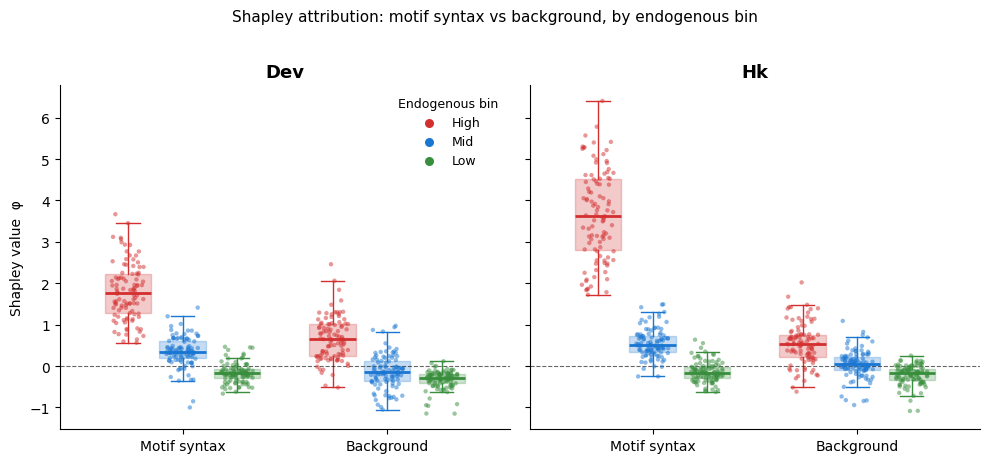

In [11]:
# ── Fig 1: Shapley values for motif syntax vs background, stratified by endogenous bin ──

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

comp_order  = ['phi_motif', 'phi_bg']
comp_labels = ['Motif syntax', 'Background']
group_width = 0.8
bar_width   = group_width / len(bin_order)  # 3 bars per group

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]

    for gi, comp in enumerate(comp_order):
        for bi, b in enumerate(bin_order):
            vals = sub_h.loc[sub_h['bin'] == b, comp].values
            x_center = gi + (bi - 1) * bar_width  # −1, 0, +1 offsets

            bp = ax.boxplot([vals], positions=[x_center], widths=bar_width * 0.85,
                            showfliers=False, patch_artist=True, zorder=2)
            bp['boxes'][0].set_facecolor(bin_colors[b])
            bp['boxes'][0].set_alpha(0.25)
            bp['boxes'][0].set_edgecolor(bin_colors[b])
            for line in bp['whiskers'] + bp['caps']:
                line.set_color(bin_colors[b])
            bp['medians'][0].set_color(bin_colors[b])
            bp['medians'][0].set_linewidth(2)

            jitter = np.random.default_rng(42).uniform(
                -bar_width * 0.3, bar_width * 0.3, len(vals))
            ax.scatter(x_center + jitter, vals, s=10, alpha=0.5,
                       color=bin_colors[b], edgecolors='none', zorder=3)

    ax.axhline(0, c='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_xticks(range(len(comp_order)))
    ax.set_xticklabels(comp_labels)
    ax.set_xlim(-0.6, len(comp_order) - 0.4)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('Shapley value  φ')
        for b, lab in zip(bin_order, bin_labels):
            ax.scatter([], [], s=30, color=bin_colors[b], label=lab)
        ax.legend(frameon=False, fontsize=9, title='Endogenous bin',
                  title_fontsize=9, loc='upper right')

plt.suptitle('Shapley attribution: motif syntax vs background, by endogenous bin',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_shapley_by_bin.png'), dpi=200, bbox_inches='tight')
plt.show()

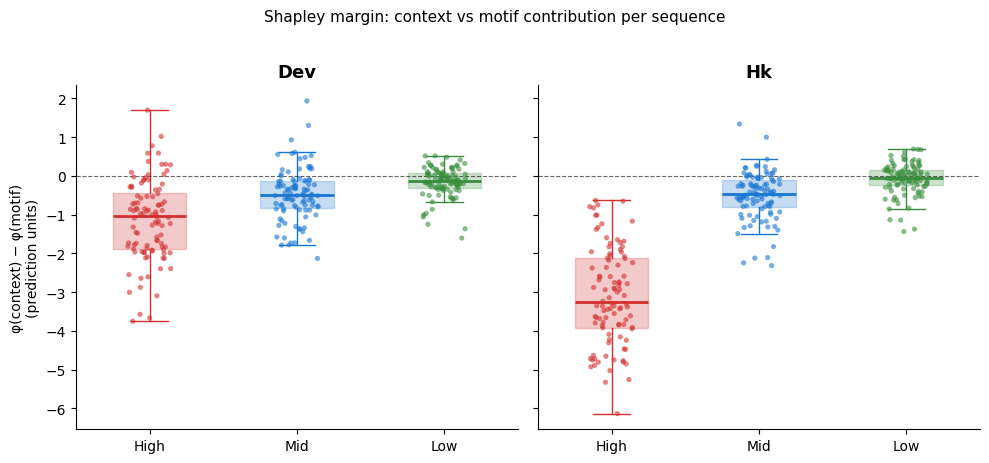

In [12]:
# ── Fig 3: Shapley difference per sequence ──
# Δ = φ(context) − φ(motif), in prediction-score units.
#   Δ > 0  → context contributes more than motif syntax
#   Δ < 0  → motif syntax contributes more
#   Δ = 0  → balanced
# Unbounded but well-behaved (no division), same units as φ itself.

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head].copy()
    sub_h['delta'] = sub_h['phi_bg'] - sub_h['phi_motif']

    data = [sub_h.loc[sub_h['bin'] == b, 'delta'].values for b in bin_order]

    bp = ax.boxplot(data, positions=range(len(bin_order)), widths=0.5,
                    showfliers=False, patch_artist=True, zorder=2)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(bin_colors[bin_order[i]])
        patch.set_alpha(0.25)
        patch.set_edgecolor(bin_colors[bin_order[i]])
    for element in ['whiskers', 'caps']:
        for i, line in enumerate(bp[element]):
            line.set_color(bin_colors[bin_order[i // 2]])
    for i, line in enumerate(bp['medians']):
        line.set_color(bin_colors[bin_order[i]])
        line.set_linewidth(2)

    for i, b in enumerate(bin_order):
        vals = data[i]
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(i + jitter, vals, s=14, alpha=0.6,
                   color=bin_colors[b], edgecolors='none', zorder=3)

    ax.axhline(0, c='k', lw=0.8, ls='--', alpha=0.6)

    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_labels)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('φ(context) − φ(motif)\n(prediction units)')

plt.suptitle('Shapley margin: context vs motif contribution per sequence',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_shap_difference.png'),
            dpi=200, bbox_inches='tight')
plt.show()

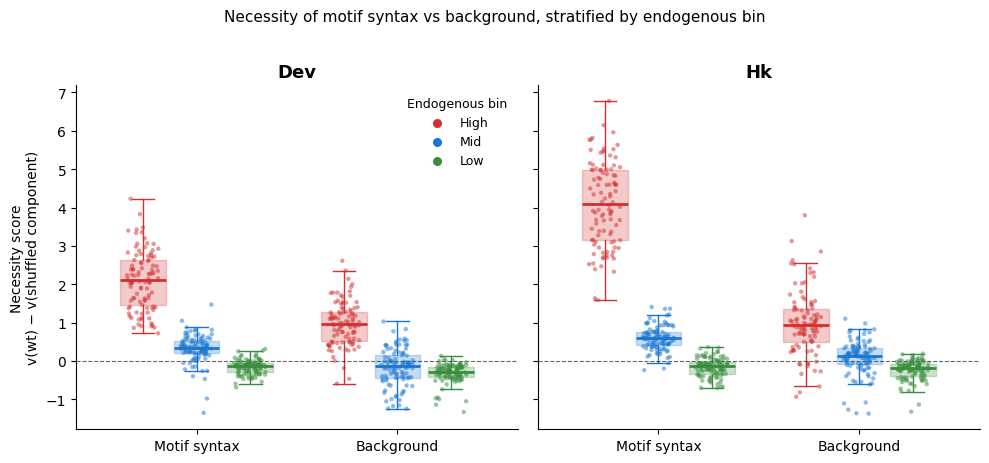

In [13]:
# ── Fig 3b: Necessity scores for motif syntax vs background, stratified by endogenous bin ──
# Necessity = drop in prediction when the component is replaced with a shuffled version.
#   necessity(motif) = v(wt) − v({bg only})   ← motifs shuffled, bg kept
#   necessity(bg)    = v(wt) − v({motif only}) ← bg shuffled, motifs kept
# Each v({·}) is already averaged over N_SHUF=20 independent dinuc shuffles.

shapley_df['nec_motif'] = shapley_df['v_wt'] - shapley_df['v_bg_only']
shapley_df['nec_bg']    = shapley_df['v_wt'] - shapley_df['v_motif_only']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

comp_order  = ['nec_motif', 'nec_bg']
comp_labels = ['Motif syntax', 'Background']
group_width = 0.8
bar_width   = group_width / len(bin_order)  # 3 bars per group

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]

    for gi, comp in enumerate(comp_order):
        for bi, b in enumerate(bin_order):
            vals = sub_h.loc[sub_h['bin'] == b, comp].values
            x_center = gi + (bi - 1) * bar_width  # -1, 0, +1 offsets

            bp = ax.boxplot([vals], positions=[x_center], widths=bar_width * 0.85,
                            showfliers=False, patch_artist=True, zorder=2)
            bp['boxes'][0].set_facecolor(bin_colors[b])
            bp['boxes'][0].set_alpha(0.25)
            bp['boxes'][0].set_edgecolor(bin_colors[b])
            for line in bp['whiskers'] + bp['caps']:
                line.set_color(bin_colors[b])
            bp['medians'][0].set_color(bin_colors[b])
            bp['medians'][0].set_linewidth(2)

            jitter = np.random.default_rng(42).uniform(
                -bar_width * 0.3, bar_width * 0.3, len(vals))
            ax.scatter(x_center + jitter, vals, s=10, alpha=0.5,
                       color=bin_colors[b], edgecolors='none', zorder=3)

    ax.axhline(0, c='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_xticks(range(len(comp_order)))
    ax.set_xticklabels(comp_labels)
    ax.set_xlim(-0.6, len(comp_order) - 0.4)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('Necessity score\nv(wt) − v(shuffled component)')
        for b, lab in zip(bin_order, bin_labels):
            ax.scatter([], [], s=30, color=bin_colors[b], label=lab)
        ax.legend(frameon=False, fontsize=9, title='Endogenous bin',
                  title_fontsize=9, loc='upper right')

plt.suptitle('Necessity of motif syntax vs background, stratified by endogenous bin',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3b_necessity_by_bin.png'),
            dpi=200, bbox_inches='tight')
plt.show()

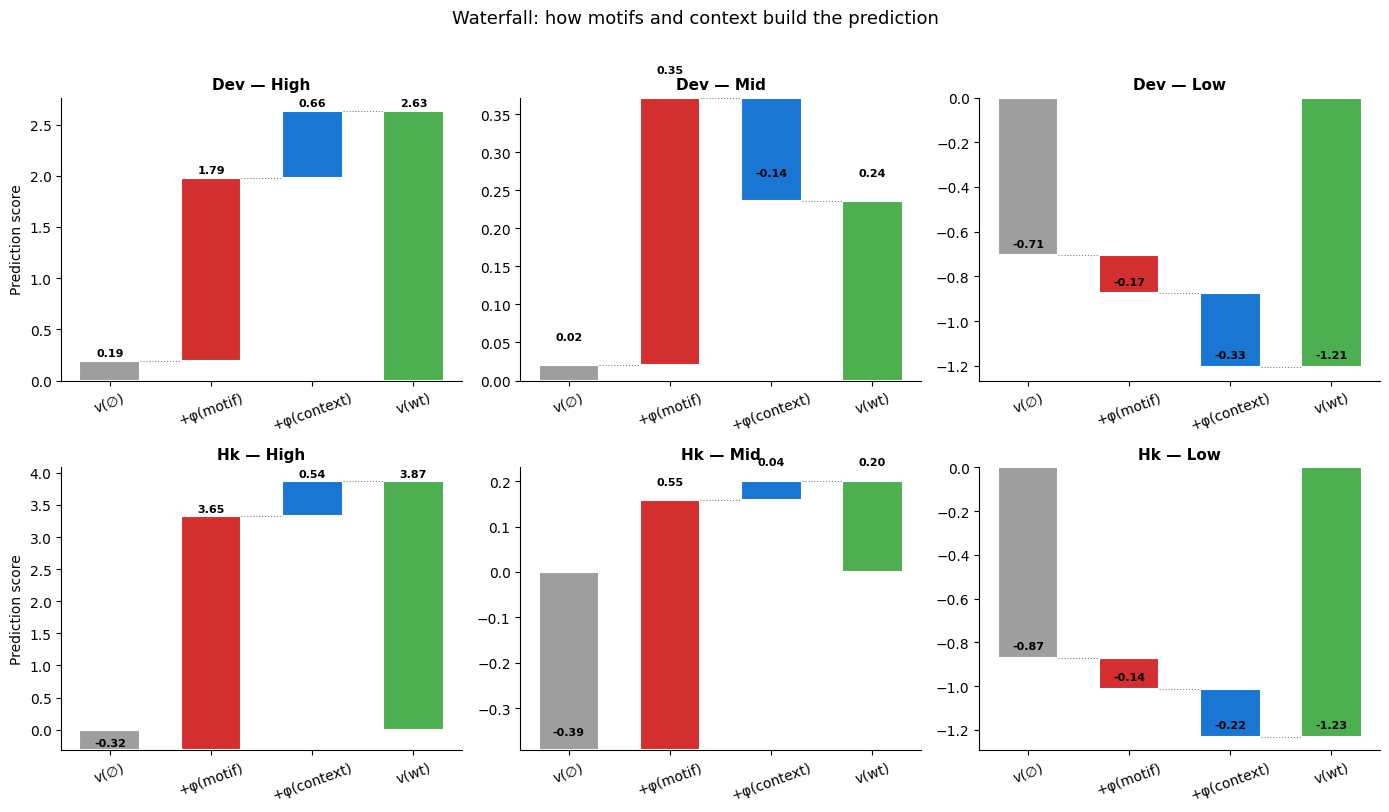

In [14]:
# ── Fig 4: Waterfall decomposition — v(∅) → +φ(motif) → +φ(bg) → v(wt) ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, head in enumerate(['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]
    for col, bin_name in enumerate(['high', 'mid', 'low']):
        ax = axes[row, col]
        sub = sub_h[sub_h['bin'] == bin_name]
        
        v_empty = sub['v_empty'].mean()
        phi_m = sub['phi_motif'].mean()
        phi_b = sub['phi_bg'].mean()
        v_wt = sub['v_wt'].mean()
        
        labels = ['v(∅)', '+φ(motif)', '+φ(context)', 'v(wt)']
        bottoms = [0, v_empty, v_empty + phi_m, 0]
        heights = [v_empty, phi_m, phi_b, v_wt]
        colors_w = ['#9E9E9E', '#D32F2F', '#1976D2', '#4CAF50']
        
        bars = ax.bar(labels, heights, bottom=bottoms, color=colors_w,
                      width=0.6, edgecolor='white', linewidth=1.5)
        
        # Connector lines between waterfall steps
        for j in range(len(labels) - 1):
            top_j = bottoms[j] + heights[j]
            ax.plot([j + 0.3, j + 0.7], [top_j, top_j],
                    c='k', lw=0.8, ls=':', alpha=0.5)
        
        # Value annotations
        for j, (b, h) in enumerate(zip(bottoms, heights)):
            ax.text(j, b + h + 0.03, f'{h:.2f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
        ax.set_title(f'{head} — {bin_name.capitalize()}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Prediction score' if col == 0 else '')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=20)

plt.suptitle('Waterfall: how motifs and context build the prediction', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_waterfall.png'), dpi=200, bbox_inches='tight')
plt.show()

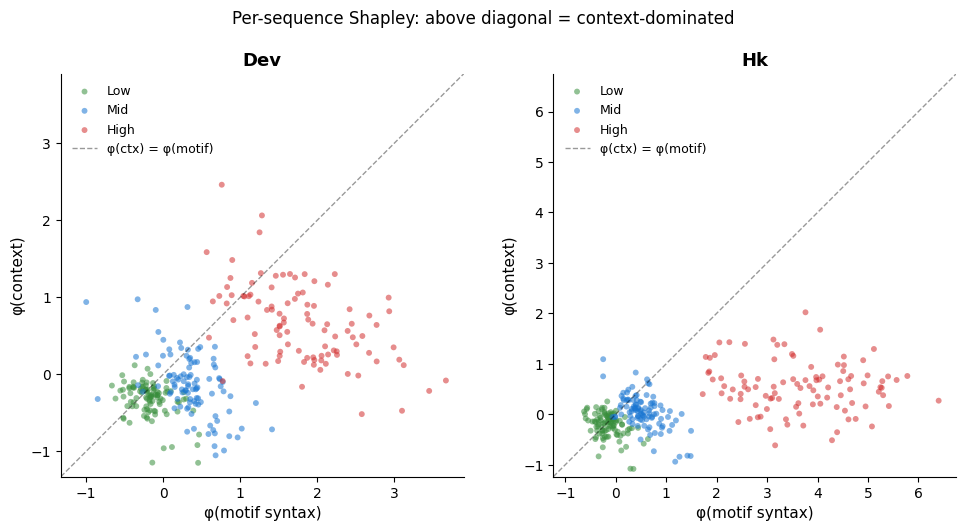

In [15]:
# ── Fig 5: Per-sequence φ(context) vs φ(motif) scatter with diagonal ──
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]
    
    for b in ['low', 'mid', 'high']:
        sub = sub_h[sub_h['bin'] == b]
        ax.scatter(sub['phi_motif'], sub['phi_bg'], s=18, alpha=0.55,
                   color=bin_colors[b], label=b.capitalize(), edgecolors='none')
    
    # Identity line (equal contribution)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.4, label='φ(ctx) = φ(motif)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    
    ax.set_xlabel('φ(motif syntax)', fontsize=11)
    ax.set_ylabel('φ(context)', fontsize=11)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Per-sequence Shapley: above diagonal = context-dominated',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_motif_vs_context_scatter.png'), dpi=200, bbox_inches='tight')
plt.show()

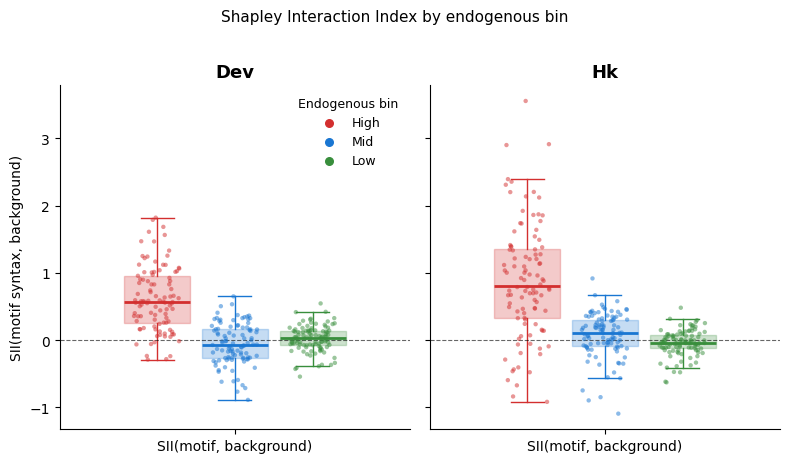

In [16]:
# ── Fig 6: SII(motif, background), stratified by endogenous bin ──
# SII = v({m,b}) − v({m}) − v({b}) + v(∅)
#   > 0  synergy (whole > sum of parts)
#   < 0  redundancy
#   = 0  additive
# The single-feature SIIs reduce to φ(motif), φ(background), so the
# deviation from additivity *is* the interaction score itself.

fig, axes = plt.subplots(1, 2, figsize=(8, 4.5), sharey=True)

comp_order  = ['sii_motif_bg']
comp_labels = ['SII(motif, background)']
group_width = 0.8
bar_width   = group_width / len(bin_order)

for ax, head in zip(axes, ['Dev', 'Hk']):
    sub_h = shapley_df[shapley_df['head'] == head]

    for gi, comp in enumerate(comp_order):
        for bi, b in enumerate(bin_order):
            vals = sub_h.loc[sub_h['bin'] == b, comp].values
            x_center = gi + (bi - 1) * bar_width

            bp = ax.boxplot([vals], positions=[x_center], widths=bar_width * 0.85,
                            showfliers=False, patch_artist=True, zorder=2)
            bp['boxes'][0].set_facecolor(bin_colors[b])
            bp['boxes'][0].set_alpha(0.25)
            bp['boxes'][0].set_edgecolor(bin_colors[b])
            for line in bp['whiskers'] + bp['caps']:
                line.set_color(bin_colors[b])
            bp['medians'][0].set_color(bin_colors[b])
            bp['medians'][0].set_linewidth(2)

            jitter = np.random.default_rng(42).uniform(
                -bar_width * 0.3, bar_width * 0.3, len(vals))
            ax.scatter(x_center + jitter, vals, s=10, alpha=0.5,
                       color=bin_colors[b], edgecolors='none', zorder=3)

    ax.axhline(0, c='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_xticks(range(len(comp_order)))
    ax.set_xticklabels(comp_labels)
    ax.set_xlim(-0.6, len(comp_order) - 0.4)
    ax.set_title(head, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('SII(motif syntax, background)')
        for b, lab in zip(bin_order, bin_labels):
            ax.scatter([], [], s=30, color=bin_colors[b], label=lab)
        ax.legend(frameon=False, fontsize=9, title='Endogenous bin',
                  title_fontsize=9, loc='upper right')

plt.suptitle('Shapley Interaction Index by endogenous bin',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig6_sii_by_bin.png'),
            dpi=200, bbox_inches='tight')
plt.show()

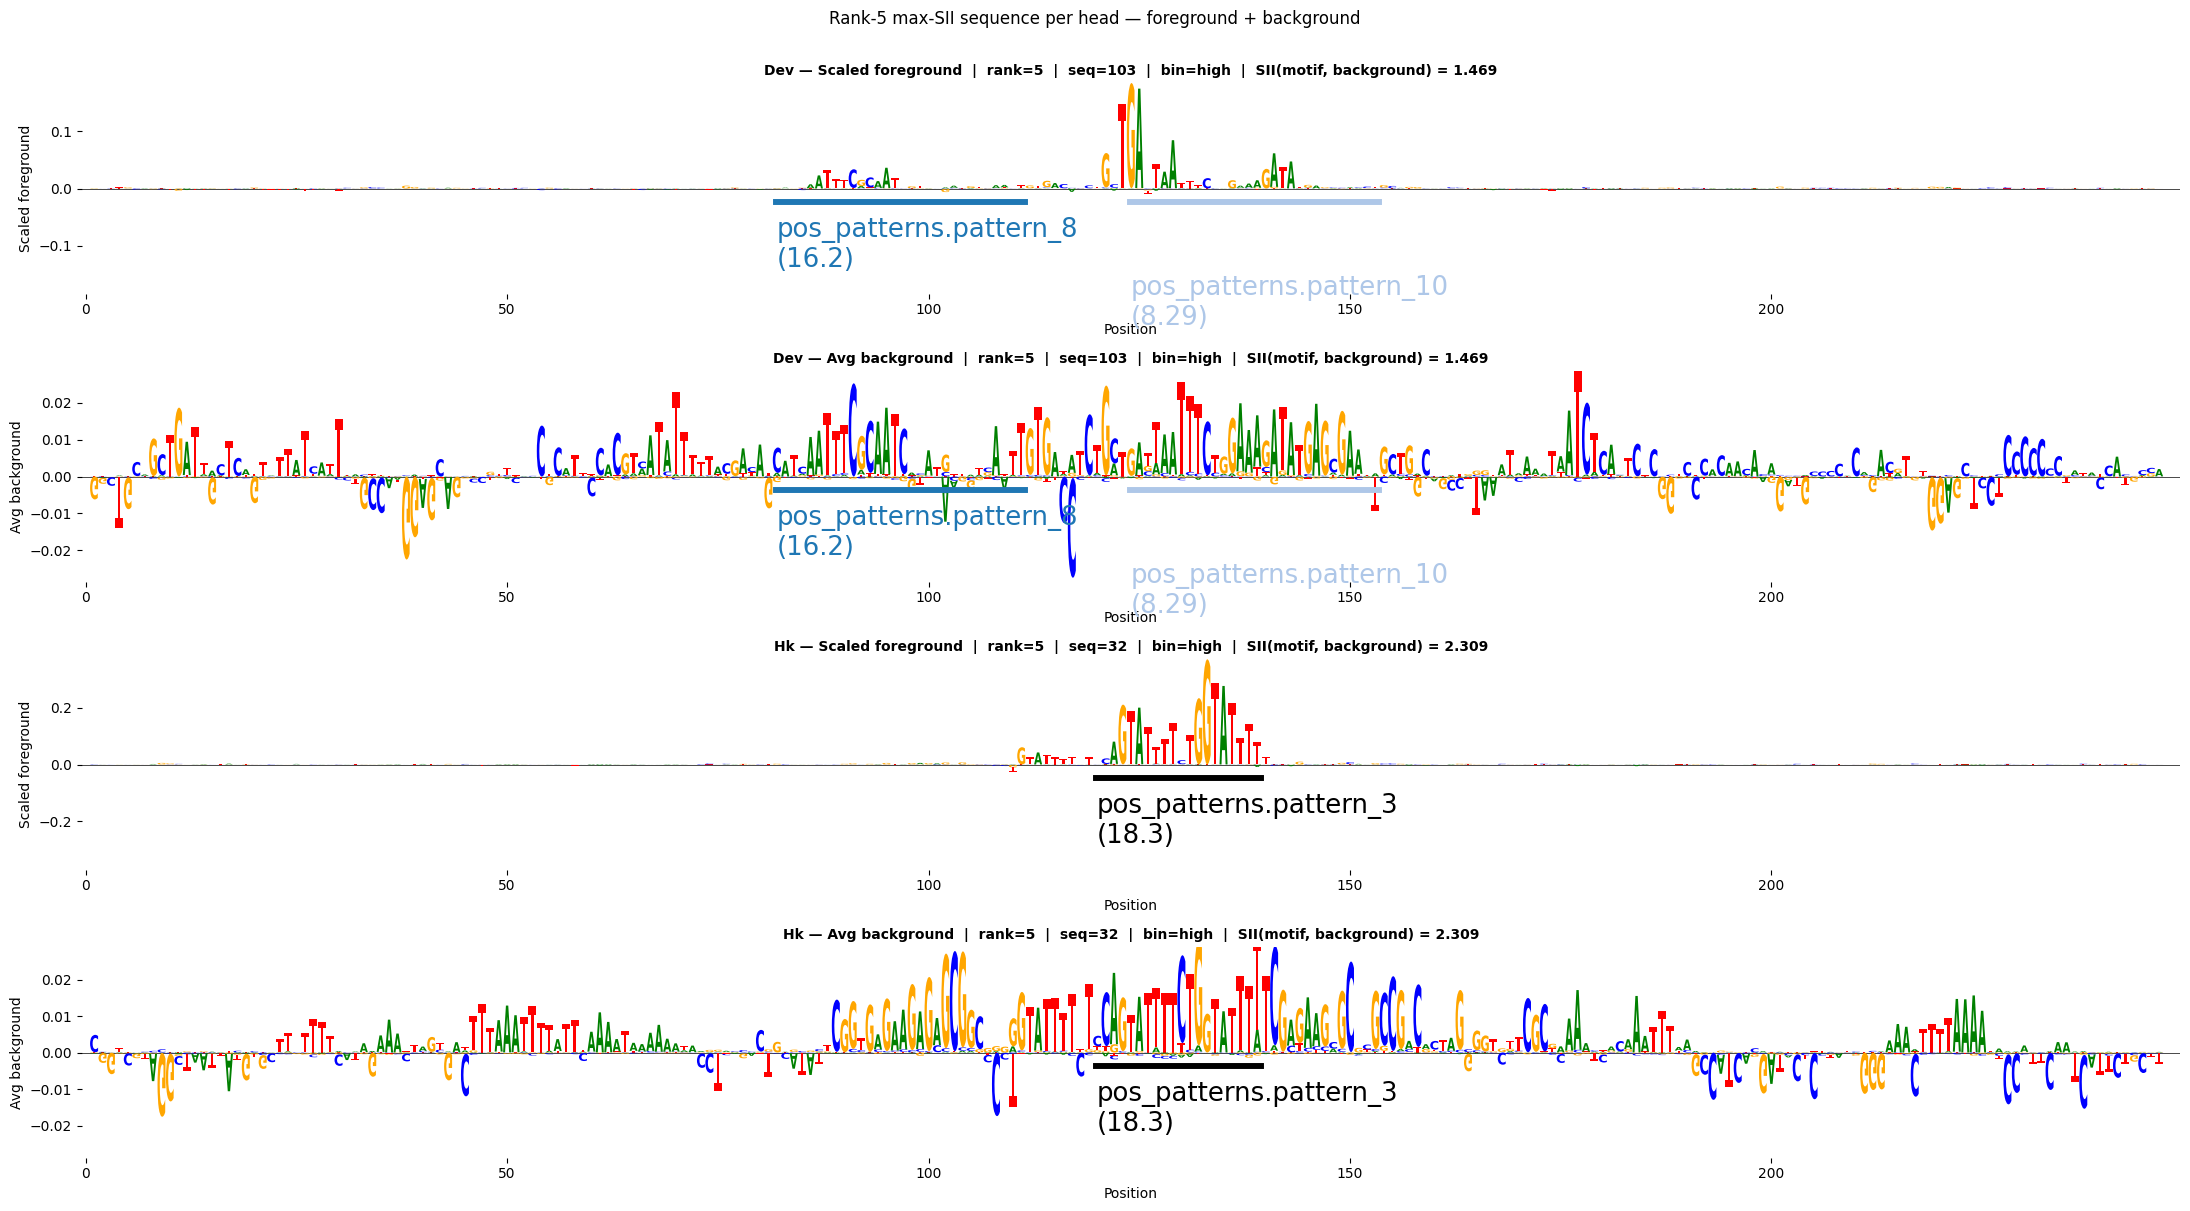

In [17]:
# ── Fig 7: Foreground + background logos for the rank-k max-SII sequence per head ──
# Set RANK = 0 for the top SII, 1 for 2nd-highest, … (applies to both Dev and Hk).
# SEAM h5 axis=1 ordering: 0=cluster_fg, 1=scaled_fg, 2=avg_background.

import h5py
from tangermeme.plot import plot_logo

RANK = 5   # ← change this to cycle through the top-SII list

ATTR_H5 = {
    'Dev': '/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/'
           'Replicating_Motif_Swap_Manuscript/SEAM_analysis/Dev_SEAM_results/'
           'Dev_task0_attributions.h5',
    'Hk':  '/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/'
           'Replicating_Motif_Swap_Manuscript/SEAM_analysis/Hk_SEAM_results/'
           'Hk_task1_attributions.h5',
}
TRACKS = [
    ('Scaled foreground', 1),
    ('Avg background',    2),
]

fig, axes = plt.subplots(4, 1, figsize=(22, 12))

for hi, head in enumerate(['Dev', 'Hk']):
    sub_sorted = (shapley_df[shapley_df['head'] == head]
                  .sort_values('sii_motif_bg', ascending=False)
                  .reset_index(drop=True))
    if RANK >= len(sub_sorted):
        raise IndexError(f"RANK={RANK} out of range for {head} ({len(sub_sorted)} seqs)")
    top = sub_sorted.iloc[RANK]
    bin_name = top['bin']
    seq_name = top['sequence_name']
    sii_val  = top['sii_motif_bg']

    attr_idx = int(bin_data[head][bin_name]['df'].iloc[seq_name]['index'])
    regions = hits_byseq[head][bin_name][seq_name].sort_values('start').reset_index(drop=True)

    with h5py.File(ATTR_H5[head], 'r') as f:
        attrs_all = f['attributions'][attr_idx, :, :, :]            # (3, L, 4)

    for ti, (track_label, track_idx) in enumerate(TRACKS):
        ax = axes[hi * 2 + ti]
        attr = attrs_all[track_idx]                                  # (L, 4)
        plot_logo(attr.T, ax=ax, annotations=regions, annot_cmap='tab20')
        ax.set_title(
            f"{head} — {track_label}  |  rank={RANK}  |  seq={seq_name}  |  "
            f"bin={bin_name}  |  SII(motif, background) = {sii_val:.3f}",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel('Position')
        ax.set_ylabel(track_label)

plt.suptitle(f'Rank-{RANK} max-SII sequence per head — foreground + background',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'fig7_max_sii_logos_rank{RANK}.png'),
            dpi=300, bbox_inches='tight')
plt.show()

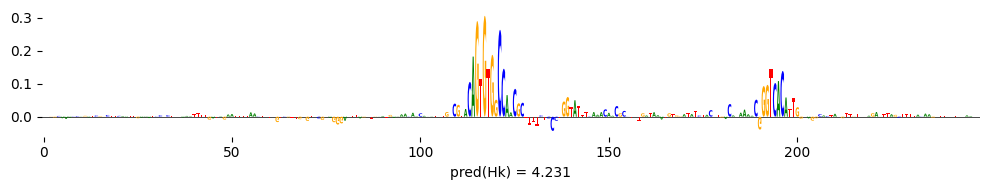

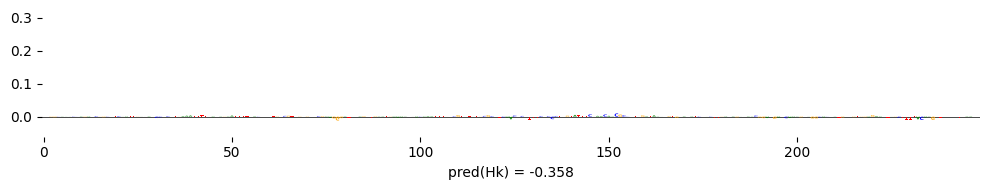

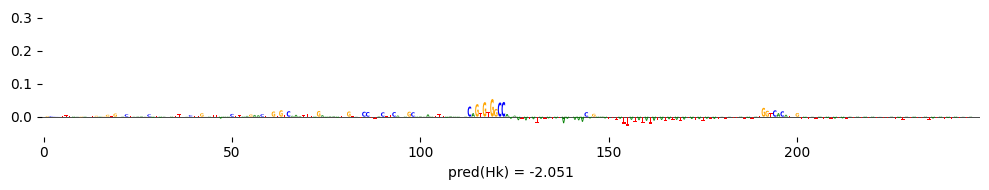

In [18]:
# ── Fig 8: Hk rank-k sequence — WT vs motif-syntax KO vs motifs-in-low-bg ──
# DeepLIFT recipe from SEAM_analysis/Hk_library_analysis.py:
#   MeanOnly wrapper + uniquify_relu_calls + additional_nonlinear_ops.
# Maps: gauge-corrected (zero-sum per position), then ohe-masked so only
# the WT base at each position carries a value.

from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear

RANK_HK = 6
HEAD = 'Hk'
head_idx = HEADS[HEAD]['head_idx']
N_SHUF_DLS = 20

class _MeanOnly(nn.Module):
    def __init__(self, student):
        super().__init__()
        self.student = student
    def forward(self, X):
        out = self.student(X)
        return out['mean'] if isinstance(out, dict) else out

def _uniquify_relu_calls(model):
    gm = fx.symbolic_trace(model)
    mods = dict(gm.named_modules())
    k = 0
    for node in gm.graph.nodes:
        if node.op == 'call_module' and isinstance(mods[node.target], nn.ReLU):
            name = f"_relu_callsite_{k}"; k += 1
            setattr(gm, name, nn.ReLU(inplace=False))
            node.target = name
    gm.recompile()
    return gm.eval()

attr_model = _MeanOnly(pytorch_model).eval()
attr_model = _uniquify_relu_calls(copy.deepcopy(attr_model)).to(device).eval()

def deeplift_attr(oh_tensor, head_i, n_shuffles=N_SHUF_DLS):
    """(4, L) DeepLIFT attribution: gauge-corrected, then masked to WT base only."""
    x = oh_tensor.unsqueeze(0).to(device).float().contiguous()
    x.requires_grad_(True)
    attr = deep_lift_shap(
        attr_model, x,
        target=head_i,
        device='cuda' if device.type == 'cuda' else 'cpu',
        batch_size=x.shape[0],
        n_shuffles=n_shuffles,
        print_convergence_deltas=False,
        additional_nonlinear_ops={nn.ReLU: _nonlinear},
        verbose=False,
    )
    a = attr.detach().cpu().numpy()[0]                 # (4, L), hypothetical
    a = a - a.mean(axis=0, keepdims=True)              # gauge
    ohe_np = oh_tensor.cpu().numpy()                   # (4, L)
    return ohe_np * a                                  # WT-masked

sub_sorted = (shapley_df[shapley_df['head'] == HEAD]
              .sort_values('sii_motif_bg', ascending=False)
              .reset_index(drop=True))
top = sub_sorted.iloc[RANK_HK]
bin_name = top['bin']
seq_name = int(top['sequence_name'])
sii_val  = top['sii_motif_bg']

ohe = bin_data[HEAD][bin_name]['ohe'][seq_name].float()
regions = (hits_byseq[HEAD][bin_name][seq_name]
           .sort_values('start').reset_index(drop=True))
starts = regions['start'].to_numpy()
ends   = regions['end'].to_numpy()
spacings = get_spacings(regions)
orig_motifs = [ohe[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]

_sh = dinucleotide_shuffle(ohe.unsqueeze(0), n=1)
if _sh.ndim == 4:
    _sh = _sh.squeeze(0) if _sh.shape[0] == 1 else _sh.squeeze(1)
shuf_one = _sh[0] if _sh.ndim == 3 else _sh
shuf_motif_pieces = [shuf_one[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]
ko_ohe = multisubstitute(
    ohe.unsqueeze(0), shuf_motif_pieces,
    spacing=spacings, start=int(starts[0])
).squeeze(0)

low_df = bin_data[HEAD]['low']['df']
donor_pos = int(low_df['evoaug_pred'].idxmin())
donor_ohe = bin_data[HEAD]['low']['ohe'][donor_pos].float()
low_bg_ohe = multisubstitute(
    donor_ohe.unsqueeze(0), orig_motifs,
    spacing=spacings, start=int(starts[0])
).squeeze(0)

wt_attr  = deeplift_attr(ohe,        head_idx)    # (4, L)
ko_attr  = deeplift_attr(ko_ohe,     head_idx)
lbg_attr = deeplift_attr(low_bg_ohe, head_idx)

with torch.no_grad():
    X = torch.stack([ohe, ko_ohe, low_bg_ohe])
    preds = predict(pytorch_model, X, batch_size=8,
                    func=lambda x: x['mean'])[:, head_idx].cpu().numpy()
pred_wt, pred_ko, pred_lbg = preds

# shared y-lims across the three logos
ymax = max(a.max() for a in (wt_attr, ko_attr, lbg_attr))
ymin = min(a.min() for a in (wt_attr, ko_attr, lbg_attr))
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

attrs = [wt_attr, ko_attr, lbg_attr]
preds_list = [pred_wt, pred_ko, pred_lbg]
fnames = [f'fig8_hk_rank{RANK_HK}_wt.pdf',
          f'fig8_hk_rank{RANK_HK}_ko.pdf',
          f'fig8_hk_rank{RANK_HK}_lowbg.pdf']

for a, pred, fname in zip(attrs, preds_list, fnames):
    fig, ax = plt.subplots(figsize=(10, 2))
    plot_logo(a, ax=ax)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_xlabel(f'pred(Hk) = {pred:.3f}')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=300, bbox_inches='tight')
    plt.show()


pred(Hk)  WT=4.561  KO=-0.311  KI=0.225  donor endogenous=-1.706


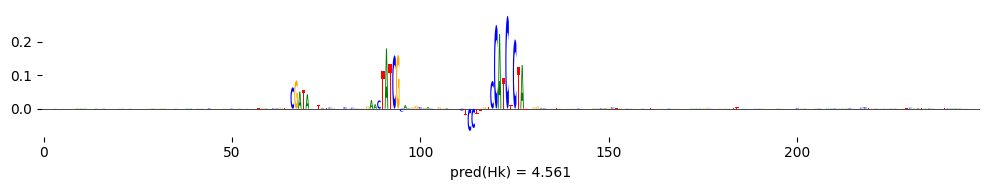

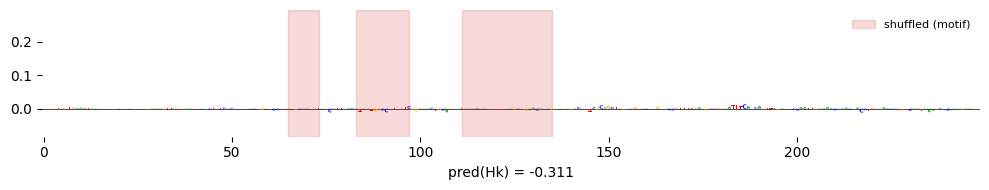

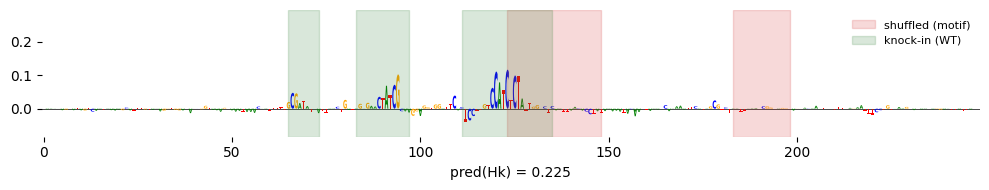

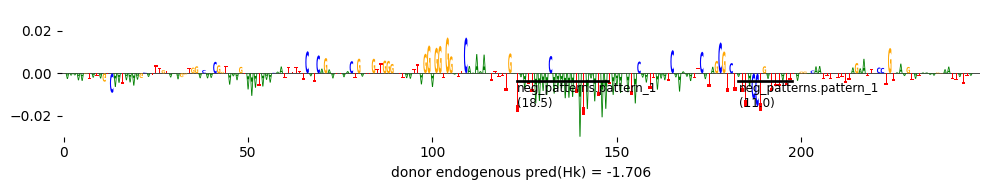

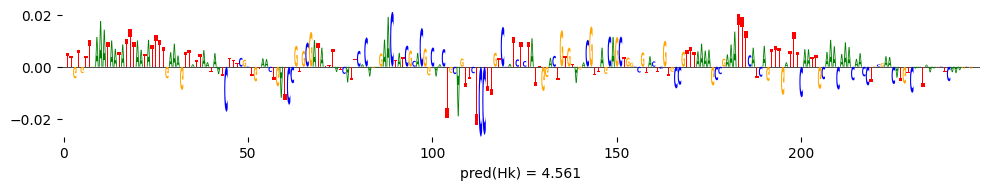

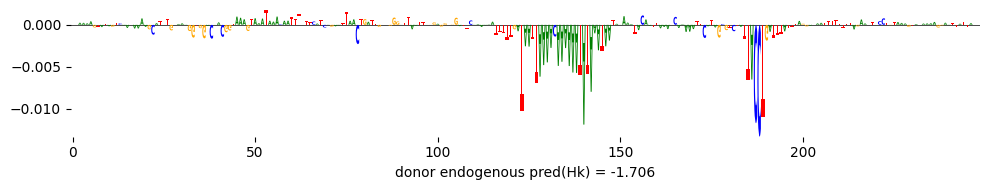

In [19]:
# ── Fig 8b: same as Fig 8 but with extra user-specified positions ──
# The SAME user-specified positions are applied to the middle and last logos,
# but with DIFFERENT semantics:
#   - middle (KO):       positions dinuc-shuffled  (on top of shuffled motifs)
#   - last   (knock-in): positions knocked-in from WT into the low-activity donor
# Shaded regions on each logo mark what changed relative to the baseline of that panel.

# ─── CONFIGURE ───
EXTRA_REGIONS = []   # list of (start, end) half-open windows, for rank_hk=6-5,30 y (155,195)
# ─────────────────

SEQ_NAME = 23           # Hk high, v_wt≈4.561, SII≈2.258
HEAD = 'Hk'
head_idx = HEADS[HEAD]['head_idx']
N_SHUF_DLS = 20

_match = shapley_df[(shapley_df['head'] == HEAD) &
                    (shapley_df['sequence_name'] == SEQ_NAME)]
if len(_match) == 0:
    raise ValueError(f"Hk seq {SEQ_NAME} not found in shapley_df")
top = _match.iloc[0]
bin_name = top['bin']
seq_name = int(top['sequence_name'])
sii_val  = top['sii_motif_bg']

ohe = bin_data[HEAD][bin_name]['ohe'][seq_name].float()
regions = (hits_byseq[HEAD][bin_name][seq_name]
           .sort_values('start').reset_index(drop=True))
starts = regions['start'].to_numpy()
ends   = regions['end'].to_numpy()
motif_regions = list(zip(starts.tolist(), ends.tolist()))
spacings = get_spacings(regions)
orig_motifs = [ohe[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]

# --- motif KO (single dinuc-shuffle rep) ---
_sh = dinucleotide_shuffle(ohe.unsqueeze(0), n=1)
if _sh.ndim == 4:
    _sh = _sh.squeeze(0) if _sh.shape[0] == 1 else _sh.squeeze(1)
shuf_one = _sh[0] if _sh.ndim == 3 else _sh
shuf_motif_pieces = [shuf_one[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]
ko_ohe = multisubstitute(
    ohe.unsqueeze(0), shuf_motif_pieces,
    spacing=spacings, start=int(starts[0])
).squeeze(0)

# --- knock-in: lowest-predicted curated Hk low-bin donor ---
# (1) KO the donor's own motifs with a dinuc-shuffle so background is "clean"
# (2) then knock in the WT motifs at the WT motif positions
low_df = bin_data[HEAD]['low']['df']
curated_low_seqs = [int(s) for s in valid_seqs[HEAD]['low'][:100]]  # first 100 curated (matches Shapley loop)
donor_pos = int(low_df.loc[curated_low_seqs, 'evoaug_pred'].idxmin())
donor_ohe = bin_data[HEAD]['low']['ohe'][donor_pos].float()
donor_regions = (hits_byseq[HEAD]['low'][donor_pos]
                 .sort_values('start').reset_index(drop=True))
donor_motif_regions = list(zip(
    donor_regions['start'].astype(int).tolist(),
    donor_regions['end'].astype(int).tolist(),
))

# step 1: shuffle out donor's own motif positions
_sh_d = dinucleotide_shuffle(donor_ohe.unsqueeze(0), n=1)
if _sh_d.ndim == 4:
    _sh_d = _sh_d.squeeze(0) if _sh_d.shape[0] == 1 else _sh_d.squeeze(1)
shuf_donor = _sh_d[0] if _sh_d.ndim == 3 else _sh_d
donor_ko = donor_ohe.clone()
for s, e in donor_motif_regions:
    donor_ko[:, s:e] = shuf_donor[:, s:e]

# step 2: knock in the WT motifs at WT motif positions
low_bg_ohe = multisubstitute(
    donor_ko.unsqueeze(0), orig_motifs,
    spacing=spacings, start=int(starts[0])
).squeeze(0)

# --- apply EXTRA regions: shuffle (KO) vs knock-in WT (low-bg) ---
def apply_extra_shuffle(base_ohe, extra_regions):
    if not extra_regions:
        return base_ohe
    out = base_ohe.clone()
    for s, e in extra_regions:
        s, e = int(s), int(e)
        sh = dinucleotide_shuffle(out.unsqueeze(0), n=1)
        if sh.ndim == 4:
            sh = sh.squeeze(0) if sh.shape[0] == 1 else sh.squeeze(1)
        sh_one = sh[0] if sh.ndim == 3 else sh
        out[:, s:e] = sh_one[:, s:e]
    return out

def apply_extra_knockin(base_ohe, source_ohe, extra_regions):
    """Copy source_ohe[:, s:e] into base_ohe[:, s:e] for each extra region."""
    if not extra_regions:
        return base_ohe
    out = base_ohe.clone()
    for s, e in extra_regions:
        s, e = int(s), int(e)
        out[:, s:e] = source_ohe[:, s:e]
    return out

ko_ohe_x     = apply_extra_shuffle(ko_ohe,     EXTRA_REGIONS)
low_bg_ohe_x = apply_extra_knockin(low_bg_ohe, ohe, EXTRA_REGIONS)

wt_attr    = deeplift_attr(ohe,          head_idx)
ko_attr    = deeplift_attr(ko_ohe_x,     head_idx)
lbg_attr   = deeplift_attr(low_bg_ohe_x, head_idx)
donor_attr = deeplift_attr(donor_ohe,    head_idx)

# --- SEAM precomputed tracks (gauge-corrected, WT-base masked) ---
def _seam_track(h5_path, attr_idx, track_slice, ohe_tensor):
    with h5py.File(h5_path, 'r') as f:
        a = f['attributions'][attr_idx, track_slice, :, :].T   # (4, L)
    a = a - a.mean(axis=0, keepdims=True)
    return ohe_tensor.cpu().numpy() * a

wt_attr_idx    = int(bin_data[HEAD][bin_name]['df'].iloc[seq_name]['index'])
donor_attr_idx = int(bin_data[HEAD]['low']['df'].iloc[donor_pos]['index'])
wt_fg_attr  = _seam_track(ATTR_H5[HEAD], wt_attr_idx,    1, ohe)        # scaled_foreground for WT high
wt_bg_attr  = _seam_track(ATTR_H5[HEAD], wt_attr_idx,    2, ohe)        # avg_background for WT high
low_fg_attr = _seam_track(ATTR_H5[HEAD], donor_attr_idx, 1, donor_ohe)  # scaled_fg for donor low

with torch.no_grad():
    X = torch.stack([ohe, ko_ohe_x, low_bg_ohe_x, donor_ohe])
    preds = predict(pytorch_model, X, batch_size=8,
                    func=lambda x: x['mean'])[:, head_idx].cpu().numpy()
pred_wt, pred_ko, pred_lbg, pred_donor = preds
print(f'pred(Hk)  WT={pred_wt:.3f}  KO={pred_ko:.3f}  KI={pred_lbg:.3f}  '
      f'donor endogenous={pred_donor:.3f}')

# Shared y-limits apply ONLY to the first three panels (WT, KO, knock-in).
ymax = max(a.max() for a in (wt_fg_attr, ko_attr, lbg_attr))
ymin = min(a.min() for a in (wt_fg_attr, ko_attr, lbg_attr))
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

SHUF_COLOR = '#D32F2F'
KI_COLOR   = '#2E7D32'
EXTRA_SHUF_COLOR = '#F9A825'

def shade(ax, regs, color, label):
    for i, (s, e) in enumerate(regs):
        ax.axvspan(s, e, color=color, alpha=0.18,
                   label=label if i == 0 else None, zorder=0)

# (attr, pred, shuf_regions, ki_regions, extra_shuf_regions, annotations, filename)
panels = [
    (wt_fg_attr, pred_wt,    [],             [],                            [],              None,           f'fig8b_hk_seq{seq_name}_wt_fg.pdf'),
    (ko_attr,    pred_ko,    motif_regions,  [],                            EXTRA_REGIONS,   None,           f'fig8b_hk_seq{seq_name}_ko.pdf'),
    (lbg_attr,   pred_lbg,   donor_motif_regions, motif_regions + EXTRA_REGIONS, [],         None,           f'fig8b_hk_seq{seq_name}_lowbg.pdf'),
    (donor_attr, pred_donor, [],             [],                            [],              donor_regions,  f'fig8b_hk_seq{seq_name}_donor.pdf'),
    (wt_bg_attr,  pred_wt,    [],             [],                            [],              None,           f'fig8b_hk_seq{seq_name}_wt_scaled_bg.pdf'),
    (low_fg_attr, pred_donor, [],             [],                            [],              None,           f'fig8b_hk_seq{seq_name}_donor_scaled_fg.pdf'),
]

for i, (a, pred, shuf_regs, ki_regs, extra_shuf_regs, annots, fname) in enumerate(panels):
    fig, ax = plt.subplots(figsize=(10, 2))
    if annots is not None:
        plot_logo(a, ax=ax, annotations=annots, annot_cmap='tab20')
    else:
        plot_logo(a, ax=ax)
    shade(ax, shuf_regs,       SHUF_COLOR,       'shuffled (motif)')
    shade(ax, extra_shuf_regs, EXTRA_SHUF_COLOR, 'shuffled (background)')
    shade(ax, ki_regs,         KI_COLOR,         'knock-in (WT)')
    if i < 3:
        ax.set_ylim(ymin - pad, ymax + pad)
    is_donor_panel = (i == 3) or (i == 5)  # donor DeepLIFT, donor scaled_fg
    xlab = (f'donor endogenous pred(Hk) = {pred:.3f}' if is_donor_panel
            else f'pred(Hk) = {pred:.3f}')
    ax.set_xlabel(xlab)
    ax.set_ylabel('')
    if shuf_regs or ki_regs or extra_shuf_regs:
        ax.legend(frameon=False, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=300, bbox_inches='tight')
    plt.show()


pred(Hk)  WT=4.561  motif-KO=0.353  motif+bg-KO=0.212


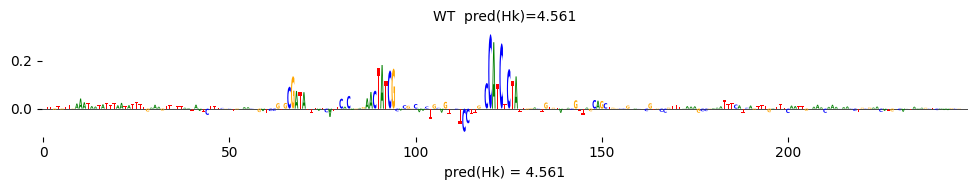

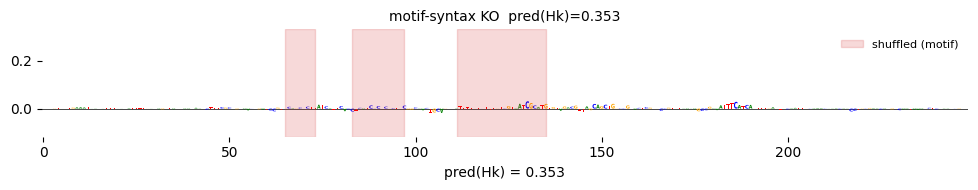

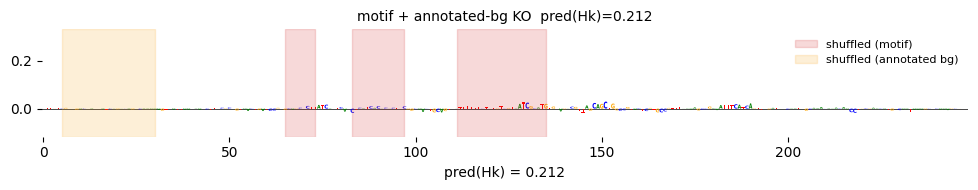

In [25]:
# ── WT vs motif-syntax KO vs motif-syntax + annotated-background KO ──
# Hk seq 23 (high bin), pred(Hk) WT ≈ 4.561, SII ≈ 2.258
# Three logos: WT, motifs shuffled, motifs + annotated background regions shuffled.

ANNOT_BG_REGIONS = [(5, 30)]  # list of (start, end) half-open windows, for rank_hk=6-5,30 y (155,195)

SEQ_NAME = 23
HEAD = 'Hk'
head_idx = HEADS[HEAD]['head_idx']

_match = shapley_df[(shapley_df['head'] == HEAD) &
                    (shapley_df['sequence_name'] == SEQ_NAME)]
top = _match.iloc[0]
bin_name = top['bin']
seq_name = int(top['sequence_name'])

ohe = bin_data[HEAD][bin_name]['ohe'][seq_name].float()
regions = (hits_byseq[HEAD][bin_name][seq_name]
           .sort_values('start').reset_index(drop=True))
starts = regions['start'].to_numpy()
ends   = regions['end'].to_numpy()
motif_regions = list(zip(starts.tolist(), ends.tolist()))
spacings = get_spacings(regions)

# Single dinuc-shuffle to draw KO bases from
_sh = dinucleotide_shuffle(ohe.unsqueeze(0), n=1)
if _sh.ndim == 4:
    _sh = _sh.squeeze(0) if _sh.shape[0] == 1 else _sh.squeeze(1)
shuf_one = _sh[0] if _sh.ndim == 3 else _sh

# Motif-syntax KO: shuffle bases at motif positions
shuf_motif_pieces = [shuf_one[:, int(s):int(e)].unsqueeze(0) for s, e in zip(starts, ends)]
ko_motif_ohe = multisubstitute(
    ohe.unsqueeze(0), shuf_motif_pieces,
    spacing=spacings, start=int(starts[0])
).squeeze(0)

# Motif + annotated-background KO: also shuffle the user-annotated background windows
ko_motif_bg_ohe = ko_motif_ohe.clone()
for s, e in ANNOT_BG_REGIONS:
    s, e = int(s), int(e)
    ko_motif_bg_ohe[:, s:e] = shuf_one[:, s:e]

wt_attr     = deeplift_attr(ohe,             head_idx)
ko_m_attr   = deeplift_attr(ko_motif_ohe,    head_idx)
ko_mb_attr  = deeplift_attr(ko_motif_bg_ohe, head_idx)

with torch.no_grad():
    X = torch.stack([ohe, ko_motif_ohe, ko_motif_bg_ohe])
    preds = predict(pytorch_model, X, batch_size=8,
                    func=lambda x: x['mean'])[:, head_idx].cpu().numpy()
pred_wt, pred_ko_m, pred_ko_mb = preds
print(f'pred(Hk)  WT={pred_wt:.3f}  motif-KO={pred_ko_m:.3f}  '
      f'motif+bg-KO={pred_ko_mb:.3f}')

ymax = max(a.max() for a in (wt_attr, ko_m_attr, ko_mb_attr))
ymin = min(a.min() for a in (wt_attr, ko_m_attr, ko_mb_attr))
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

SHUF_COLOR       = '#D32F2F'
EXTRA_SHUF_COLOR = '#F9A825'

def _shade(ax, regs, color, label):
    for i, (s, e) in enumerate(regs):
        ax.axvspan(s, e, color=color, alpha=0.18,
                   label=label if i == 0 else None, zorder=0)

panels = [
    (wt_attr,    pred_wt,    [],            [],                f'WT  pred(Hk)={pred_wt:.3f}',                       f'fig9_hk_seq{seq_name}_wt.pdf'),
    (ko_m_attr,  pred_ko_m,  motif_regions, [],                f'motif-syntax KO  pred(Hk)={pred_ko_m:.3f}',         f'fig9_hk_seq{seq_name}_motif_ko.pdf'),
    (ko_mb_attr, pred_ko_mb, motif_regions, ANNOT_BG_REGIONS,  f'motif + annotated-bg KO  pred(Hk)={pred_ko_mb:.3f}', f'fig9_hk_seq{seq_name}_motif_bg_ko.pdf'),
]

for a, pred, mregs, bregs, title, fname in panels:
    fig, ax = plt.subplots(figsize=(10, 2))
    plot_logo(a, ax=ax)
    _shade(ax, mregs, SHUF_COLOR,       'shuffled (motif)')
    _shade(ax, bregs, EXTRA_SHUF_COLOR, 'shuffled (annotated bg)')
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'pred(Hk) = {pred:.3f}')
    ax.set_ylabel('')
    if mregs or bregs:
        ax.legend(frameon=False, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=300, bbox_inches='tight')
    plt.show()


In [21]:
shapley_df.loc[                                                                                                                                          
      (shapley_df['head'] == 'Hk'),                                                                                                                        
      ['bin','sequence_name','v_wt','sii_motif_bg']                                                                                                        
  ].query("v_wt > 4.55 and v_wt < 4.57").sort_values('v_wt')
  

,bin,sequence_name,v_wt,sii_motif_bg
307,high,7,4.552445,1.769267
396,high,145,4.552794,-0.193621
321,high,23,4.561389,1.738067
